# ARISE — 06 · Ablation Studies

Reproductions of the paper's ablation experiments:

| study | paper | what it tests |
|-------|-------|---------------|
| **Substructure detector** | Table VI | k-core region proposal vs. classic community detection |
| **Score components** | Table VII | the averaging term (Eq. 2) and node vs. node-pair weighting (Eq. 9) |
| **Fusion strategy** | Table VIII | max / sum / weighted fusion of the two scores |
| **Imbalanced ratios** | Table X / Fig. 8 | AUC vs. α as the topology:attribute anomaly ratio changes |

All studies reuse the `arise.ablation` module.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # make the `arise` package importable
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
from arise.data import load_dataset, inject_anomalies, PAPER_INJECTION
from arise.pipeline import run_arise, normalize_features, node_embeddings
from arise import ablation as ab
import numpy as np

clean = load_dataset("cora")
inj = PAPER_INJECTION["Cora"]
graph = inject_anomalies(clean, seed=42, **inj)
result, model = run_arise(graph, alpha=0.8, epochs=60, lr=0.003, weight_decay=1e-5,
                          attr_rounds=4, seed=42, return_model=True, verbose=False)
emb = node_embeddings(normalize_features(graph), model)
mm = lambda x: (x - x.min()) / (x.max() - x.min() + 1e-12)
norm_t = np.asarray(result["scores"]["topology_norm"])
norm_a = np.asarray(result["scores"]["attribute_norm"])
labels = np.asarray(result["labels"])
print("overall AUC:", result["metrics"]["overall"]["auc"])

overall AUC: 0.8792


## 1. Substructure-detector ablation (Table VI)
Does k-core beat generic community detection for finding anomalous substructures?

In [3]:
rows = ab.substructure_detector_ablation(graph, emb)
print(f"{'method':<22}{'AUC(topo)':>10}{'AUC(all)':>10}{'#subs':>8}")
for r in rows:
    if 'error' in r: print(r['method'], 'ERROR', r['error']); continue
    print(f"{r['method']:<22}{r['auc_topology']:>10}{r['auc_overall']:>10}{r['num_substructures']:>8}")

method                 AUC(topo)  AUC(all)   #subs
k-core (ARISE)               1.0    0.7638      23
Greedy Modularity         0.5741    0.5182     102
Label Propagation         0.7665    0.6417     480
Kernighan-Lin             0.6543     0.567       2


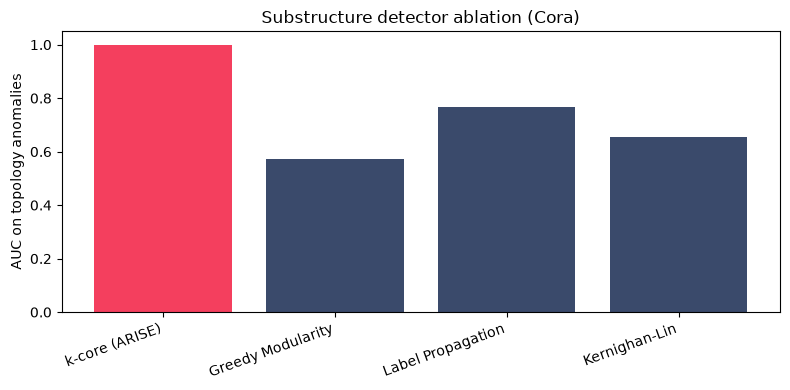

In [4]:
methods = [r['method'] for r in rows if 'error' not in r]
topo = [r['auc_topology'] for r in rows if 'error' not in r]
colors = ['#f43f5e' if m.startswith('k-core') else '#3a4a6b' for m in methods]
plt.figure(figsize=(8,4)); plt.bar(methods, topo, color=colors)
plt.ylabel('AUC on topology anomalies'); plt.xticks(rotation=20, ha='right')
plt.title('Substructure detector ablation (Cora)'); plt.ylim(0,1.05); plt.tight_layout(); plt.show()

## 2. Score-component ablation (Table VII)

In [5]:
for r in ab.score_component_ablation(graph, emb):
    print(f"{r['variant']:<32} AUC(topo)={r['auc_topology']}  AUC(all)={r['auc_overall']}")

Avg sim + node count (ARISE)     AUC(topo)=1.0  AUC(all)=0.7638
W/o averaging (sum sim)          AUC(topo)=1.0  AUC(all)=0.7634
Node-pair count weight           AUC(topo)=0.9995  AUC(all)=0.7636


## 3. Fusion-strategy ablation (Table VIII)

In [6]:
for r in ab.fusion_strategy_ablation(labels, mm(norm_t), mm(norm_a), alpha=0.8):
    print(f"{r['strategy']:<22} AUC={r['auc']}")

Max                    AUC=0.8832
Sum                    AUC=0.8829
Weight (alpha=0.8)     AUC=0.8792


## 4. Imbalanced-ratio α analysis (Table X / Fig. 8)
Retrain at different topology:attribute ratios and sweep α. *(takes a few minutes — 5 retrainings)*

  ratio 9:1 -> 9 cliques (135 topo), 15 attr


  ratio 7:3 -> 7 cliques (105 topo), 45 attr


  ratio 1:1 -> 5 cliques (75 topo), 75 attr


  ratio 3:7 -> 3 cliques (45 topo), 105 attr


  ratio 1:9 -> 1 cliques (15 topo), 135 attr


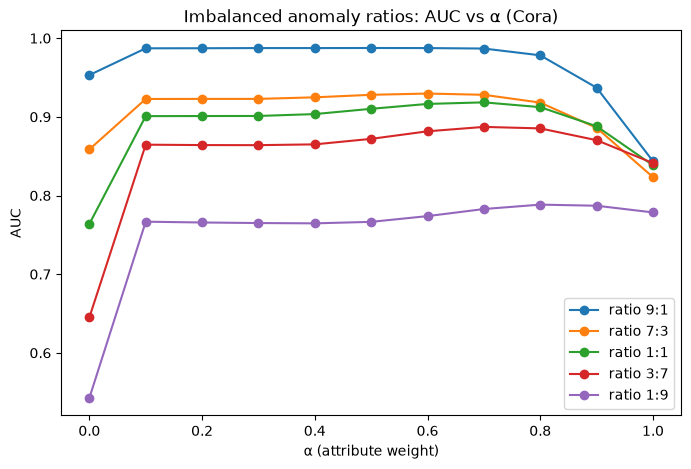

In [7]:
imb = ab.imbalance_alpha_analysis(clean, total_anomalies=150, clique_size=15,
                                  epochs=60, lr=0.003, seed=42, verbose=True)
plt.figure(figsize=(8,5))
for s in imb['series']:
    plt.plot(imb['alphas'], s['auc_by_alpha'], '-o', label=f"ratio {s['ratio']}")
plt.xlabel('α (attribute weight)'); plt.ylabel('AUC'); plt.legend()
plt.title('Imbalanced anomaly ratios: AUC vs α (Cora)'); plt.show()

## Summary
- **k-core** clearly beats community-detection methods for the region-proposal step — the substructure-aware design is the right inductive bias (paper Table VI).
- The averaging term and node-count weighting are sensible defaults (Table VII).
- **Weighted** fusion is the most comprehensive choice (Table VIII).
- Under imbalance, the optimal α shifts: attribute-heavy graphs prefer higher α, but intermediate α (fusion) wins in balanced settings — exactly the paper's Fig. 8 story.

These match the conclusions in the paper, completing the ablation reproduction.